# RAG & Embedding Foundations
**Module 3: GenAI & Agents | ~90 min**

- What is RAG?
- Retrieval pipeline
- Text to vectors
- Similarity scores
- Improving accuracy through context
- Intro to vector DBs (Chroma/FAISS)

> Everything in this notebook runs **fully offline** — no API key needed. We use TF-IDF instead of a neural embedding model so every cell executes instantly and deterministically.


In [ ]:
!pip install scikit-learn chromadb faiss-cpu --quiet


## 1. What is RAG?

- LLMs only know what was in their training data — nothing private, nothing brand-new
- **RAG (Retrieval-Augmented Generation)** fixes this: fetch relevant text first, then let the model answer using it
- Same idea as giving a tool to look something up (Session 3) — except the "tool" is a search over your own documents

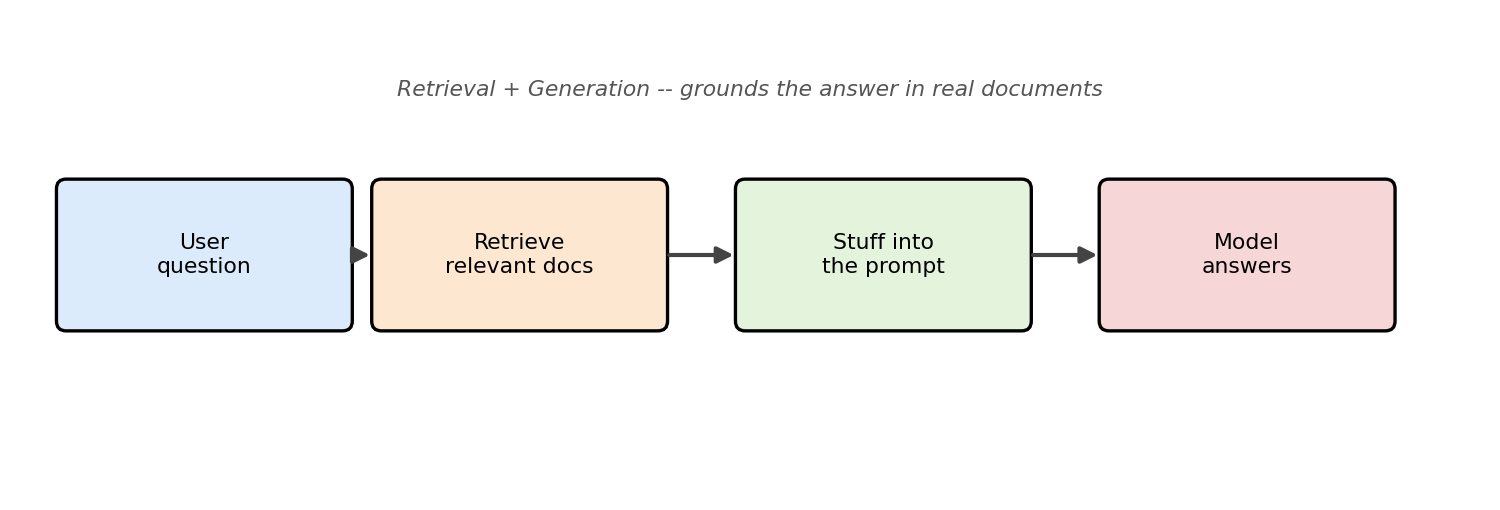


## 2. The Retrieval Pipeline

- **Indexing (once, offline):** documents → chunk → embed → store in a vector DB
- **Query time:** embed the question → find the most similar chunks → pass them to the model

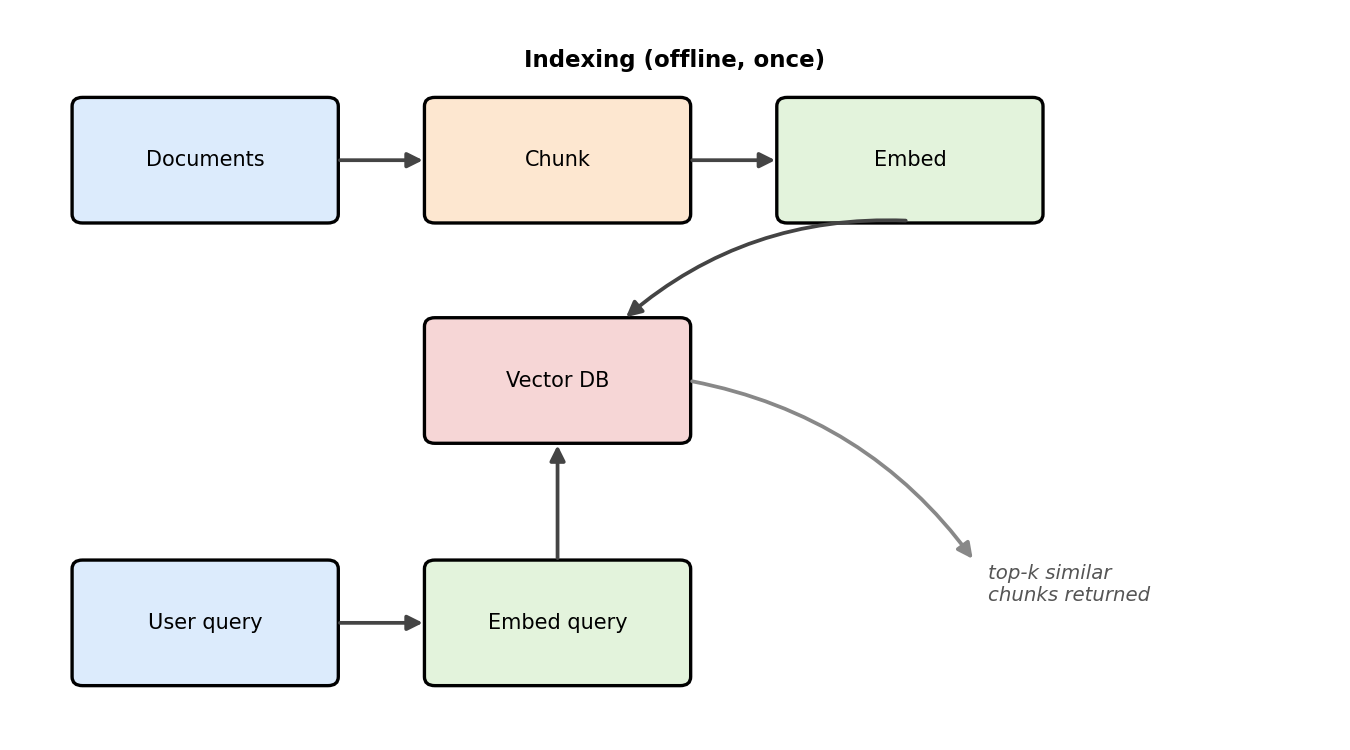


## 3. Text to Vectors

- A vector is just a list of numbers that represents meaning
- **TF-IDF** is a simple, classic way to build one: it counts words, weighted by how distinctive they are across documents
- (Production systems use neural embedding models instead — same idea, richer vectors)


In [1]:
from sklearn.feature_extraction.text import TfidfVectorizer

documents = [
    "Masai School trains students in full stack web development and AI/ML.",
    "The IIT Patna AI/ML program covers Python, data science, and deep learning.",
    "Cricket is a popular sport played between two teams of eleven players.",
    "Retrieval-augmented generation combines a search step with a language model.",
]

vectorizer = TfidfVectorizer()
doc_vectors = vectorizer.fit_transform(documents)

print("Vocabulary size:", len(vectorizer.vocabulary_))
print("Vector shape:", doc_vectors.shape)
print("First document, first 8 dims:", doc_vectors[0].toarray()[0][:8])


Vocabulary size: 42
Vector shape: (4, 42)
First document, first 8 dims: [0.239, 0.239, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


## 4. Similarity Scores

- **Cosine similarity** measures the angle between two vectors — closer direction = closer meaning
- 1.0 = identical direction, 0 = unrelated

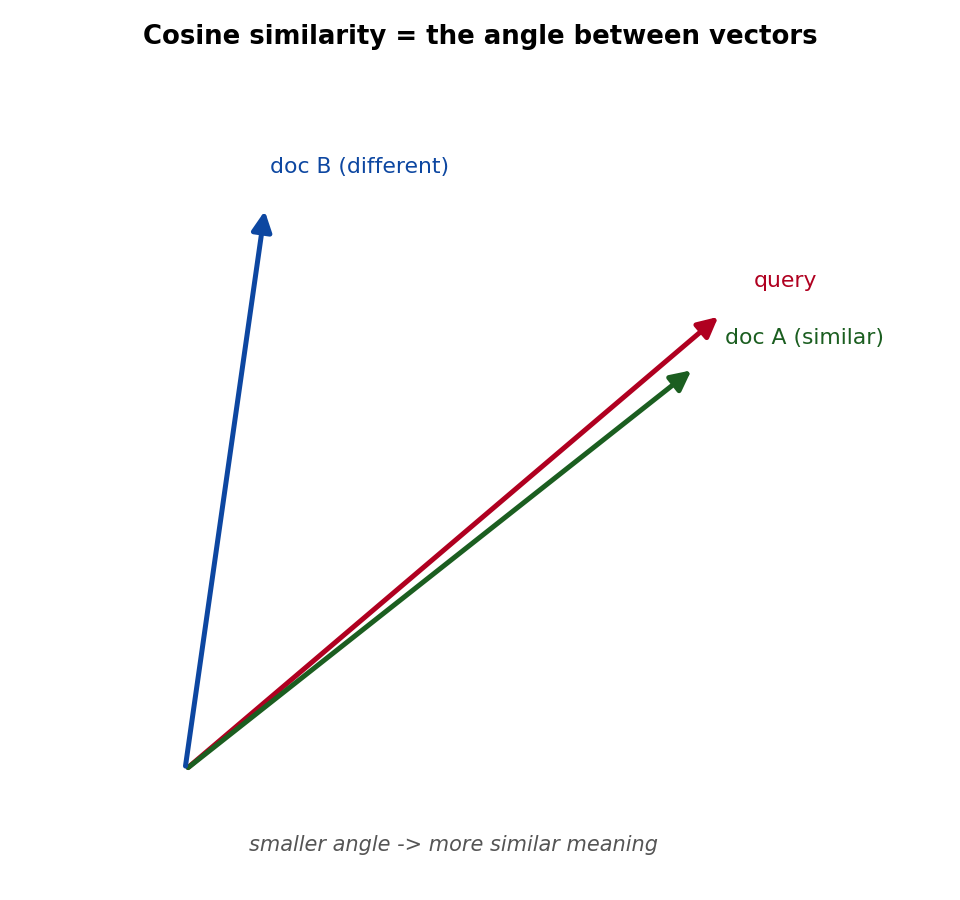


In [2]:
from sklearn.metrics.pairwise import cosine_similarity

query = "What does Masai School teach about machine learning?"
query_vector = vectorizer.transform([query])

scores = cosine_similarity(query_vector, doc_vectors)[0]
for doc, score in zip(documents, scores):
    print(f"{score:.3f}  {doc}")

print("\nMost similar:", documents[scores.argmax()])


0.350  Masai School trains students in full stack web development and AI/ML.
0.168  The IIT Patna AI/ML program covers Python, data science, and deep learning.
0.000  Cricket is a popular sport played between two teams of eleven players.
0.000  Retrieval-augmented generation combines a search step with a language model.

Most similar: Masai School trains students in full stack web development and AI/ML.


## 5. Improving Accuracy Through Context

- **Chunk size** — too big wastes context, too small loses meaning
- **Overlap** — repeat a few words between chunks so no idea gets cut in half
- **Top-k** — how many chunks to retrieve; too few misses info, too many adds noise


In [3]:
long_text = ("Masai School runs AI/ML programs for IIT and IIM partner institutions. "
             "The curriculum covers Python, statistics, machine learning, and deep learning. "
             "Students build projects using real datasets and deploy models to production. "
             "Instructors include industry mentors from top technology companies.")

words = long_text.split()
chunk_size, overlap = 12, 4
chunks, start = [], 0
while start < len(words):
    chunks.append(" ".join(words[start:start + chunk_size]))
    start += chunk_size - overlap

for i, c in enumerate(chunks):
    print(f"Chunk {i}: {c}")


Chunk 0: Masai School runs AI/ML programs for IIT and IIM partner institutions. The
Chunk 1: IIM partner institutions. The curriculum covers Python, statistics, machine learning, and deep
Chunk 2: machine learning, and deep learning. Students build projects using real datasets and
Chunk 3: using real datasets and deploy models to production. Instructors include industry mentors
Chunk 4: Instructors include industry mentors from top technology companies.


Notice the repeated words at each chunk boundary (the `overlap`) — that's what stops a sentence from being split with no context on either side.


## 6. Vector DBs: Chroma & FAISS

- A vector DB stores embeddings and answers "which vectors are closest to this one?" — fast, even over millions of vectors
- **Chroma** — simple, Python-native, good for prototyping
- **FAISS** — a lower-level library from Meta, very fast, widely used in production
- Both work with **any** embedding vectors — including our TF-IDF ones above


In [4]:
import chromadb

chroma_client = chromadb.Client()
collection = chroma_client.create_collection(name="masai_docs")

collection.add(
    ids=[f"doc{i}" for i in range(len(documents))],
    embeddings=doc_vectors.toarray().tolist(),
    documents=documents,
)

results = collection.query(query_embeddings=query_vector.toarray().tolist(), n_results=2)
for doc, dist in zip(results["documents"][0], results["distances"][0]):
    print(f"distance={dist:.3f}  {doc}")


distance=1.299  Masai School trains students in full stack web development and AI/ML.
distance=1.665  The IIT Patna AI/ML program covers Python, data science, and deep learning.


In [5]:
import faiss
import numpy as np

dim = doc_vectors.shape[1]
index = faiss.IndexFlatL2(dim)
index.add(doc_vectors.toarray().astype("float32"))

distances, indices = index.search(query_vector.toarray().astype("float32"), k=2)
for idx, dist in zip(indices[0], distances[0]):
    print(f"distance={dist:.3f}  {documents[idx]}")


distance=1.299  Masai School trains students in full stack web development and AI/ML.
distance=1.665  The IIT Patna AI/ML program covers Python, data science, and deep learning.


Same ranking from both — Chroma and FAISS are just different tools for the same nearest-neighbor search.


## Summary

| Concept | One-liner |
|---|---|
| RAG | Retrieve relevant text, then let the model answer using it |
| Retrieval pipeline | chunk → embed → store (once); embed query → search → answer (every request) |
| Text to vectors | Turn text into numbers that capture meaning (TF-IDF here, neural embeddings in production) |
| Similarity scores | Cosine similarity = angle between vectors; smaller angle = more similar |
| Chunking | Size + overlap decide how much context survives the split |
| Vector DBs | Chroma / FAISS — store vectors, answer "what's closest?" fast |

**Try:**
1. Add a 5th document about a totally different topic and see it always score near 0.
2. Change `chunk_size` to 6 and `overlap` to 0 — see how many more chunks you get, and whether meaning breaks.
3. Ask FAISS/Chroma for `n_results=4` / `k=4` and see all documents ranked, not just the top 2.
